### Holiday Package Prediciton

The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [3]:
df = pd.read_csv("./Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning

### Handling Missing values

1. Handling Missing values
2. Handling Duplicates
3. Check data type
4. Understand the dataset


In [4]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [5]:
df["Gender"].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [6]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [7]:
df["TypeofContact"].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [8]:
df["Gender"] = df["Gender"].replace("Fe Male", "Female")
df["MaritalStatus"] = df["MaritalStatus"].replace("Single", "Unmarried")

In [9]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [10]:
# checking missing values
features_with_na = [feature for feature in df.columns if df[feature].isnull().sum() > 0]

# how many percetage of total are missing values, rounded to 5
for feature in features_with_na:
    print(feature, ": ", np.round(df[feature].isnull().mean() * 100, 5))

Age :  4.62357
TypeofContact :  0.51146
DurationOfPitch :  5.13502
NumberOfFollowups :  0.92062
PreferredPropertyStar :  0.53191
NumberOfTrips :  2.86416
NumberOfChildrenVisiting :  1.35025
MonthlyIncome :  4.76678


In [11]:
df[features_with_na].select_dtypes(exclude=["object"]).describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Imputing Null Values

1. Impute Median for Age column
2. Impute Mode for TypeofContact
3. Impute Median for DurationOfPitch
4. Imput Mode for NumberOfFollowups, as it is a discrete feature
5. Impute Mode for PreferredProperyStar
6. Impute Median for NumberOfTips
7. Imput Mode for NumberOfChildrenVisiting
8. Impute Median for MonthlyIncome


In [12]:
df.Age.fillna(df.Age.median(), inplace=True)
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)

In [13]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [14]:
df.drop("CustomerID", axis=1, inplace=True)

## Feature Engineering


In [15]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [16]:
# make a new column called TotalVisiting which is the sum of NumberOfChildrenVisiting and NumberOfPersonVisiting
df["TotalVisiting"] = df["NumberOfChildrenVisiting"] + df["NumberOfPersonVisiting"]

df.drop(["NumberOfChildrenVisiting", "NumberOfPersonVisiting"], axis=1, inplace=True)

In [17]:
# feature column is not eqaul to object
numeric_features = [feature for feature in df.columns if df[feature].dtypes != "O"]

print("Number of numerical features: ", len(numeric_features))

Number of numerical features:  12


In [18]:
# feature column is equal to object
categorical_features = [feature for feature in df.columns if df[feature].dtypes == "O"]

print("Number of categorical features: ", len(categorical_features))

Number of categorical features:  6


In [19]:
# discreate features
discrete_features = [
    feature for feature in numeric_features if len(df[feature].unique()) < 25
]
print("Number of discrete features: ", len(discrete_features))

Number of discrete features:  9


In [20]:
# Continuous features
continuous_features = [
    feature for feature in numeric_features if feature not in discrete_features
]
print("Number of continuous features: ", len(continuous_features))

Number of continuous features:  3


In [21]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


## Training


In [22]:
X = df.drop("ProdTaken", axis=1)
y = df["ProdTaken"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

In [24]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric__transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", categorical_transformer, categorical_features),
        ("StandardScaler", numeric__transformer, numerical_features),
    ]
)

In [25]:
X_train = preprocessor.fit_transform(X_train)

In [26]:
X_test = preprocessor.transform(X_test)

In [35]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)

In [36]:
models = {
    "Random Forest": RandomForestClassifier(),
    "AdaBoost Classifier": AdaBoostClassifier(),
}

In [37]:
for i in range(len(list(models.keys()))):
    model = list(models.values())[i]
    model_name = list(models.keys())[i]

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(f"Model: {model_name}")
    print("Model Performance on Training Set")
    print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
    print(f"Training F1 Score: {f1_score(y_train, y_train_pred)}")
    print(f"Training Precision: {precision_score(y_train, y_train_pred)}")
    print(f"Training Recall: {recall_score(y_train, y_train_pred)}")
    print(f"Training ROC AUC Score: {roc_auc_score(y_train, y_train_pred)}")

    print("-" * 59)

    print("Model Performance on Testing Set")
    print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred)}")
    print(f"Testing F1 Score: {f1_score(y_test, y_test_pred)}")
    print(f"Testing Precision: {precision_score(y_test, y_test_pred)}")
    print(f"Testing Recall: {recall_score(y_test, y_test_pred)}")
    print(f"Testing ROC AUC Score: {roc_auc_score(y_test, y_test_pred)}")

    print("=" * 35)
    print()

Model: Random Forest
Model Performance on Training Set
Training Accuracy: 1.0
Training F1 Score: 1.0
Training Precision: 1.0
Training Recall: 1.0
Training ROC AUC Score: 1.0
-----------------------------------------------------------
Model Performance on Testing Set
Testing Accuracy: 0.9355828220858896
Testing F1 Score: 0.7675276752767528
Testing Precision: 0.9454545454545454
Testing Recall: 0.6459627329192547
Testing ROC AUC Score: 0.8193093958353922

Model: AdaBoost Classifier
Model Performance on Training Set
Training Accuracy: 0.8508951406649616
Training F1 Score: 0.5038297872340426
Training Precision: 0.7115384615384616
Training Recall: 0.38998682476943347
Training ROC AUC Score: 0.6759518382812576
-----------------------------------------------------------
Model Performance on Testing Set
Testing Accuracy: 0.8568507157464212
Testing F1 Score: 0.4262295081967213
Testing Precision: 0.6265060240963856
Testing Recall: 0.32298136645962733
Testing ROC AUC Score: 0.6425188350045995



In [41]:
# hyperparameter tuning for Random Forest Classifier

rf_params = {
    "max_depth": [None, 5, 8, 15, 10],
    "max_features": ["auto", 5, 7, 8],
    "min_samples_split": [2, 5, 8, 15, 20],
    "n_estimators": [100, 200, 500, 1000],
}

ada_params = {
    "n_estimators": [50, 100, 200, 500, 1000],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

In [42]:
# models list for hyperparameters tuning

randomcv_models = [
    ("RF", RandomForestClassifier(), rf_params),
    ("AdaBoost", AdaBoostClassifier(), ada_params),
]

In [43]:
from sklearn.model_selection import RandomizedSearchCV

model_params = {}
for name, model, params in randomcv_models:
    randomcv = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1,
    )
    randomcv.fit(X_train, y_train)
    model_params[name] = randomcv.best_params_

print("Best Model Parameters:")
for model_name in model_params:
    print(f"{model_name}: {model_params[model_name]}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Model Parameters:
RF: {'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}
AdaBoost: {'n_estimators': 1000, 'learning_rate': 0.1}


In [44]:
# training the model with best parameters
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, min_samples_split=2, max_features=7, max_depth=None
    ),
    "AdaBoost Classifier": AdaBoostClassifier(
        n_estimators=1000,
        learning_rate=0.1,
    ),
}

for i in range(len(list(models.keys()))):
    model = list(models.values())[i]
    model_name = list(models.keys())[i]

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(f"Model: {model_name}")
    print("Model Performance on Training Set")
    print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
    print(f"Training F1 Score: {f1_score(y_train, y_train_pred)}")
    print(f"Training Precision: {precision_score(y_train, y_train_pred)}")
    print(f"Training Recall: {recall_score(y_train, y_train_pred)}")
    print(f"Training ROC AUC Score: {roc_auc_score(y_train, y_train_pred)}")

    print("-" * 59)

    print("Model Performance on Testing Set")
    print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred)}")
    print(f"Testing F1 Score: {f1_score(y_test, y_test_pred)}")
    print(f"Testing Precision: {precision_score(y_test, y_test_pred)}")
    print(f"Testing Recall: {recall_score(y_test, y_test_pred)}")
    print(f"Testing ROC AUC Score: {roc_auc_score(y_test, y_test_pred)}")

    print("=" * 35)
    print()

Model: Random Forest
Model Performance on Training Set
Training Accuracy: 1.0
Training F1 Score: 1.0
Training Precision: 1.0
Training Recall: 1.0
Training ROC AUC Score: 1.0
-----------------------------------------------------------
Model Performance on Testing Set
Testing Accuracy: 0.9427402862985685
Testing F1 Score: 0.7985611510791367
Testing Precision: 0.9487179487179487
Testing Recall: 0.6894409937888198
Testing ROC AUC Score: 0.8410485262701749

Model: AdaBoost Classifier
Model Performance on Training Set
Training Accuracy: 0.8514066496163682
Training F1 Score: 0.4881057268722467
Training Precision: 0.7367021276595744
Training Recall: 0.36495388669301715
Training ROC AUC Score: 0.6667676447111547
-----------------------------------------------------------
Model Performance on Testing Set
Testing Accuracy: 0.8578732106339468
Testing F1 Score: 0.41350210970464135
Testing Precision: 0.6447368421052632
Testing Recall: 0.30434782608695654
Testing ROC AUC Score: 0.6356500452344208



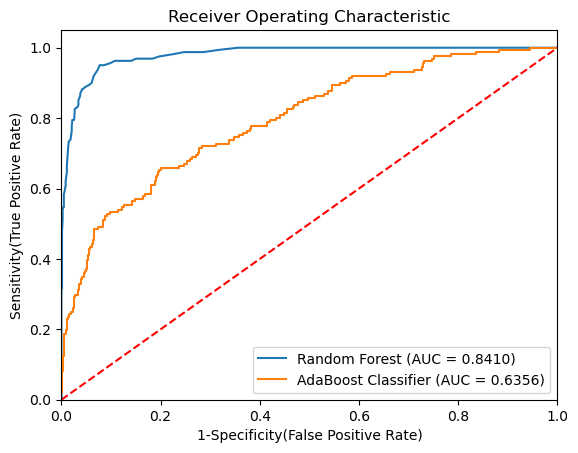

In [45]:
auc_models = [
    {
        "label": "Random Forest",
        "model": RandomForestClassifier(
            n_estimators=100, min_samples_split=2, max_features=7, max_depth=None
        ),
        "auc": 0.8410,
    },
    {
        "label": "AdaBoost Classifier",
        "model": AdaBoostClassifier(
            n_estimators=1000,
            learning_rate=0.1,
        ),
        "auc": 0.6356,
    },
]

for algo in auc_models:
    model = algo["model"]
    model.fit(X_train, y_train)

    fpr, trp, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, trp, label=f"{algo['label']} (AUC = {algo['auc']:.4f})")

# Custom settings for the plot
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("1-Specificity(False Positive Rate)")
plt.ylabel("Sensitivity(True Positive Rate)")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()